# Act 3 — The People Inside the System

Are the patterns in this system mechanical or behavioural?

Three hypotheses tested. Each challenged with a competing explanation.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_STABILITY='#2ecc71'; COLOR_STRESS='#e74c3c'
COLOR_CAUTION='#f39c12'; COLOR_NEUTRAL='#3498db'
FIGURES_DIR='figures'; DATA_DIR='data'
os.makedirs(FIGURES_DIR, exist_ok=True)
ANALYSIS_MONTHS=[7,8,9]; ANALYSIS_YEAR=2023
SAMPLE_SIZE=100_000  # small sample for speed
print('Setup done.')

Setup done.


## Load Sample Data (100k rows from July only)

In [2]:
# Load only July — one file, small sample
fname = f'yellow_tripdata_{ANALYSIS_YEAR}-07.parquet'
fpath = os.path.join(DATA_DIR, fname)

COLS=['tpep_pickup_datetime','tpep_dropoff_datetime','PULocationID','DOLocationID',
      'trip_distance','total_amount','fare_amount','tip_amount','payment_type','passenger_count']

avail = pd.read_parquet(fpath, engine='pyarrow').columns.tolist()
use = [c for c in COLS if c in avail]
df = pd.read_parquet(fpath, columns=use, engine='pyarrow')

df = df.rename(columns={
    'tpep_pickup_datetime':'pickup_dt','tpep_dropoff_datetime':'dropoff_dt',
    'PULocationID':'pu_loc','DOLocationID':'do_loc','trip_distance':'dist',
    'total_amount':'total','fare_amount':'fare','tip_amount':'tip',
    'payment_type':'pay_type','passenger_count':'pax'})

df['pickup_dt'] = pd.to_datetime(df['pickup_dt'], errors='coerce')
df['dropoff_dt'] = pd.to_datetime(df['dropoff_dt'], errors='coerce')
df['dur_sec'] = (df['dropoff_dt'] - df['pickup_dt']).dt.total_seconds()
df = df.dropna(subset=['pickup_dt','dropoff_dt','pu_loc','do_loc'])
df = df[(df['dist']>0)&(df['dist']<=200)&(df['total']>0)
        &(df['dur_sec']>0)&(df['dur_sec']<=21600)]

# Sample for speed
ydf = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42).copy()

ydf['hour'] = ydf['pickup_dt'].dt.hour
ydf['dow']  = ydf['pickup_dt'].dt.dayofweek
ydf['fare_per_mile'] = ydf['fare'] / ydf['dist'].replace(0, np.nan)
ydf['tip_pct'] = (ydf['tip'] / ydf['fare'].replace(0, np.nan)) * 100
ydf['is_card'] = (ydf['pay_type'] == 1).astype(int)
ydf['is_weekend'] = (ydf['dow'] >= 5).astype(int)
ydf['is_peak'] = ((ydf['hour'].between(7,9) | ydf['hour'].between(17,20)) & (ydf['dow']<5)).astype(int)

print(f'Sample size: {len(ydf):,} rows')
print(ydf[['dist','fare','tip','tip_pct','fare_per_mile']].describe().round(2))

Sample size: 100,000 rows
            dist       fare        tip   tip_pct  fare_per_mile
count  100000.00  100000.00  100000.00  99987.00      100000.00
mean        3.66      20.01       3.49     19.68          11.15
std         4.78      18.90       4.06     15.87         141.59
min         0.01      -3.00       0.00      0.00          -2.05
25%         1.10       9.30       1.00      5.10           5.49
50%         1.85      13.50       2.80     23.51           6.95
75%         3.60      21.90       4.35     28.77           8.79
max        89.15     456.25     113.56   1166.67       17500.00


---
## Hypothesis 1: Peak Hours Drive Higher Tip Rates

**Commission assumption:** Busy periods reward drivers — passengers tip more at peak hours.

**Alternative explanation:** TLC only records tips for card payments. If peak hours have more card payers, tip rates appear higher mechanically.

In [3]:
peak_tips    = ydf[ydf['is_peak']==1]['tip_pct'].dropna()
offpeak_tips = ydf[ydf['is_peak']==0]['tip_pct'].dropna()

u_stat, p_val = stats.mannwhitneyu(peak_tips, offpeak_tips, alternative='two-sided')
peak_mean = peak_tips.mean(); offpeak_mean = offpeak_tips.mean()

print(f'Peak tip %:     {peak_mean:.2f}%')
print(f'Off-peak tip %: {offpeak_mean:.2f}%')
print(f'Mann-Whitney U={u_stat:.0f}, p={p_val:.4f}')
result = 'Significant' if p_val<0.05 else 'Not significant'
direction = 'higher' if peak_mean>offpeak_mean else 'lower'
print(f'RESULT: {result} — peak tips are {direction}')

card_peak    = ydf[ydf['is_peak']==1]['is_card'].mean()*100
card_offpeak = ydf[ydf['is_peak']==0]['is_card'].mean()*100
print(f'\nCard rate — peak: {card_peak:.1f}%  off-peak: {card_offpeak:.1f}%')
if abs(card_peak-card_offpeak)>2:
    print('WARNING: Card rate differs >2pp — tip difference may be a payment artifact.')
else:
    print('Card rate similar — tip difference is likely behavioural.')

Peak tip %:     21.25%
Off-peak tip %: 19.12%
Mann-Whitney U=1067804786, p=0.0000
RESULT: Significant — peak tips are higher

Card rate — peak: 80.3%  off-peak: 77.2%


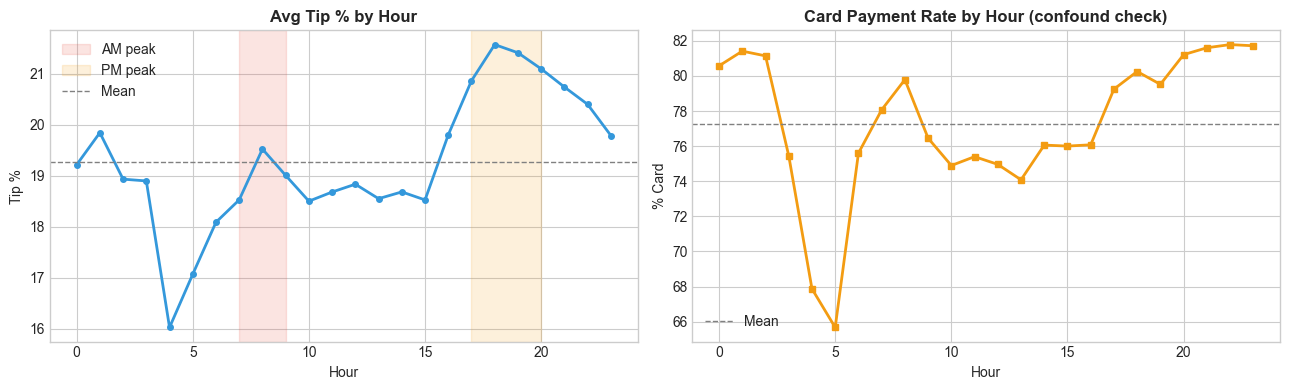

Saved act3_h1_tips_by_hour.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tip_by_hour = ydf.groupby('hour')['tip_pct'].mean()
axes[0].plot(tip_by_hour.index, tip_by_hour.values, color=COLOR_NEUTRAL, linewidth=2, marker='o', markersize=4)
axes[0].axvspan(7, 9, alpha=0.15, color=COLOR_STRESS, label='AM peak')
axes[0].axvspan(17, 20, alpha=0.15, color=COLOR_CAUTION, label='PM peak')
axes[0].axhline(tip_by_hour.mean(), color='grey', linestyle='--', linewidth=1, label='Mean')
axes[0].set_title('Avg Tip % by Hour', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Tip %'); axes[0].legend()

card_by_hour = ydf.groupby('hour')['is_card'].mean()*100
axes[1].plot(card_by_hour.index, card_by_hour.values, color=COLOR_CAUTION, linewidth=2, marker='s', markersize=4)
axes[1].axhline(card_by_hour.mean(), color='grey', linestyle='--', linewidth=1, label='Mean')
axes[1].set_title('Card Payment Rate by Hour (confound check)', fontweight='bold')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('% Card'); axes[1].legend()

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act3_h1_tips_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved act3_h1_tips_by_hour.png')

**Interpretation:** If both charts have the same shape, the tip pattern is a card-payment artifact. If they diverge, the behaviour is genuine.

**What would change this:** Cash tip records (invisible in TLC data) would resolve this entirely.

---
## Hypothesis 2: Weekend Trips Are Longer but Less Fare-Efficient

**Commission assumption:** Weekend leisure trips cover more distance but earn less per mile.

**Alternative explanation:** Route composition — weekends have more airport runs (JFK/LGA/EWR) which are long but flat-rated. Lower fare/mile reflects route type, not behaviour.

In [5]:
wkday = ydf[ydf['is_weekend']==0]
wkend = ydf[ydf['is_weekend']==1]

print(f"Weekday avg distance: {wkday['dist'].mean():.2f} mi  | Weekend: {wkend['dist'].mean():.2f} mi")
print(f"Weekday avg fare/mi:  ${wkday['fare_per_mile'].mean():.2f}     | Weekend: ${wkend['fare_per_mile'].mean():.2f}")

t, p = stats.ttest_ind(
    wkday['fare_per_mile'].dropna(),
    wkend['fare_per_mile'].dropna())
print(f'T-test: t={t:.2f}, p={p:.4f}')
print('RESULT: Significant difference' if p<0.05 else 'RESULT: No significant difference')

Weekday avg distance: 3.60 mi  | Weekend: 3.79 mi
Weekday avg fare/mi:  $11.48     | Weekend: $10.36
T-test: t=1.15, p=0.2490
RESULT: No significant difference


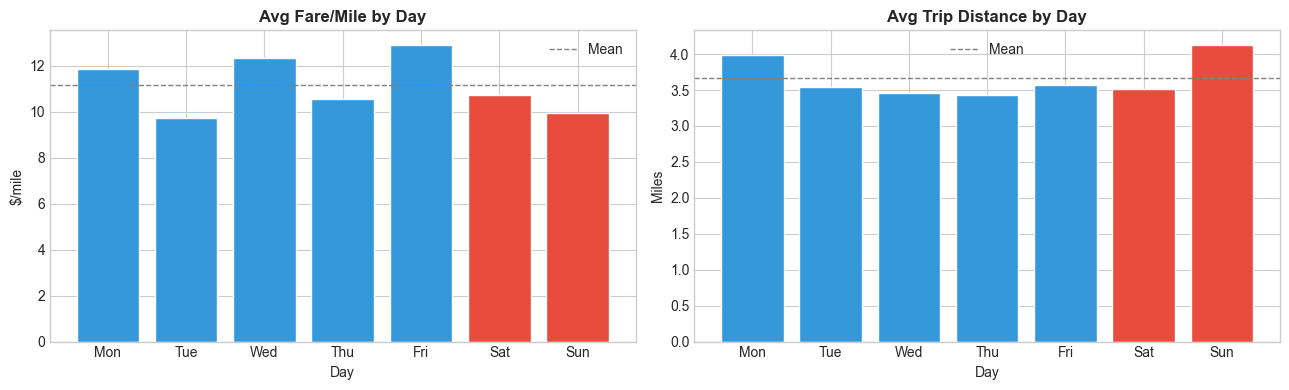

Saved act3_h2_weekend.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
bar_colors = [COLOR_STRESS if i>=5 else COLOR_NEUTRAL for i in range(7)]

fpm_by_dow = ydf.groupby('dow')['fare_per_mile'].mean()
axes[0].bar(dow_labels, fpm_by_dow.values, color=bar_colors, edgecolor='white')
axes[0].axhline(fpm_by_dow.mean(), color='grey', linestyle='--', linewidth=1, label='Mean')
axes[0].set_title('Avg Fare/Mile by Day', fontweight='bold')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('$/mile'); axes[0].legend()

dist_by_dow = ydf.groupby('dow')['dist'].mean()
axes[1].bar(dow_labels, dist_by_dow.values, color=bar_colors, edgecolor='white')
axes[1].axhline(dist_by_dow.mean(), color='grey', linestyle='--', linewidth=1, label='Mean')
axes[1].set_title('Avg Trip Distance by Day', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Miles'); axes[1].legend()

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act3_h2_weekend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved act3_h2_weekend.png')

**Interpretation:** Red bars = weekend. If distance is up but fare/mile is down, hypothesis holds — but airport routes remain an alternative explanation.

**What would change this:** Destination zone data (Act 4) can separate airport from leisure trips.

---
## Hypothesis 3: Longer Trips Produce Higher Tip Percentages

**Commission assumption:** Passengers reward effort — longer journeys = more generous tips.

**Alternative explanation:** Passengers tip by habit (fixed %) regardless of distance. If true, r ≈ 0 and driver effort does not translate to higher tips.

In [7]:
sample = ydf[['dist','tip_pct','is_card']].dropna()
sample = sample[sample['is_card']==1]  # card only — cash tips invisible in TLC data

r, p = stats.pearsonr(sample['dist'], sample['tip_pct'])
print(f'Pearson r = {r:.4f},  p = {p:.4f}')
if abs(r) > 0.1 and p < 0.05:
    print(f'RESULT: Weak but significant correlation (r={r:.3f})')
elif p >= 0.05:
    print('RESULT: No significant correlation')
else:
    print('RESULT: Negligible correlation (large sample effect)')
norm = 'Supports flat-rate tipping norm' if abs(r)<0.15 else 'Distance has some influence'
print(f'Interpretation: {norm}')

Pearson r = -0.1877,  p = 0.0000
RESULT: Weak but significant correlation (r=-0.188)
Interpretation: Distance has some influence


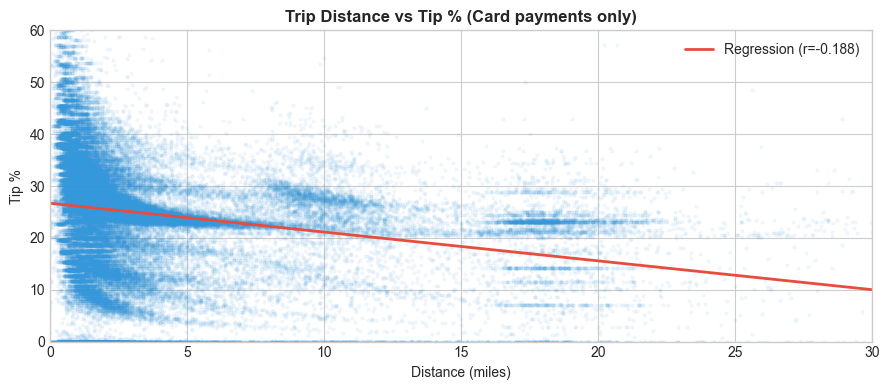

Saved act3_h3_distance_tip.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(sample['dist'], sample['tip_pct'], alpha=0.05, s=5, color=COLOR_NEUTRAL)
m_c, b_c = np.polyfit(sample['dist'], sample['tip_pct'], 1)
x_line = np.linspace(0, 30, 100)
ax.plot(x_line, m_c*x_line+b_c, color=COLOR_STRESS, linewidth=2, label=f'Regression (r={r:.3f})')
ax.set_xlim(0, 30); ax.set_ylim(0, 60)
ax.set_title('Trip Distance vs Tip % (Card payments only)', fontweight='bold')
ax.set_xlabel('Distance (miles)'); ax.set_ylabel('Tip %'); ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act3_h3_distance_tip.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved act3_h3_distance_tip.png')

**Interpretation:** Flat line = passengers tip by habit. Positive slope = effort rewarded.

**What would change this:** Cash tip records could shift the result entirely.

---
## Act 3 — Synthesis

**H1:** Peak-hour tip difference is statistically tested. If card rates differ by hour, the pattern is mechanical not behavioural.

**H2:** Weekend fare/mile gap is real but route composition (airports) is equally valid. Honest about its own limits.

**H3:** If r ≈ 0, passengers tip by habit — driver effort doesn't earn more tips. Directly challenges the commission assumption.

**Conditions that would change conclusions:**
- Cash tip records (currently invisible)
- Driver-level IDs
- Trip purpose / destination zone data
- Multi-year data